# ML741 Assignment 2: Nearest Neighbours vs Classification Trees

**N.H. Chowdhury (26243881)**

This notebook walks through the whole study in order. Each section explains what
is happening in plain language, runs the code, and shows the result.

## How to read this

Every number reported in the write-up is loaded from the saved result files in
`results/`, so what you see here is exactly what went into the report. The cells
that fit models are demonstrations. By default they run on a small sample so the
notebook finishes in a couple of minutes. Set `QUICK = False` in the next cell to
reproduce the full study, which takes a few hours.

## What each script in `code/` does

| File | What it does |
|---|---|
| `a2_common.py` | Shared setup. Loads the data, and builds the two preprocessing recipes (one per model). Everything else imports from here. |
| `a2_step1_audit.py` | Looks at the raw data and measures the problems: how lopsided the classes are, missing values, skew, duplicates, correlations. |
| `a2_step2_tune.py` | Searches for the best settings for both models, by trying every combination on a grid. |
| `a2_step2b_resume.py` | Restarts the search from where it stopped, so a crash does not mean starting over. |
| `a2_step2c_retune_knn.py` | Re-runs the k-NN search after the scaling method changed, since that changes which settings are best. |
| `a2_step3_ablation.py` | Turns each preprocessing step off one at a time to check it actually helps. |
| `a2_step3b_scaling.py` | Compares five ways of squashing numbers onto the same range, plus whether to drop correlated features. |
| `a2_step4_evaluate.py` | The first full evaluation of all four setups using 10-fold cross-validation. |
| `a2_step5_tables.py` | Turns the result files into LaTeX tables and into the numbers the report quotes. Nothing is typed by hand. |
| `a2_step5b_revision.py` | The extra tables and numbers added in the final revision. |
| `a2_step6_retune_f1.py` | Re-runs the settings search using macro F1 as the target instead of balanced accuracy. |
| `a2_step8_thresholds.py` | Fits the "decision multipliers" for the tree, which change how the final class is picked. |
| `a2_step9_knn_thresholds.py` | The same for k-NN, and re-checks the best neighbourhood size under the new rule. |
| `a2_step10_all_configs.py` | Final evaluation of all four setups under the new decision rule, plus the statistics. |
| `a2_step11b_supplement.py` | Fills in the leftover measurements: precision, training scores, timings. |
| `a2_step12_rebuild_tables.py` | Rewrites the result files into the shape the table generator expects. |
| `ceiling_export.py` | Works out the best score anybody could possibly get on this data. |
| `regen_figures.py` | Draws all the charts used in the report. |
| `verify_independent.py` | Re-checks every fact about the data using completely separate code, to catch mistakes. |
| `verify_revision.py` | Checks the numbers in the report match the result files. |
| `check_writing_rules.py` | Checks the report against the 34 writing rules. |

## 1. Setup

Load the libraries and point at the dataset.

In [1]:
import os, sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sys.path.insert(0, "code")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
%matplotlib inline

# Set this to the dataset location on your machine.
os.environ.setdefault("A2_DATA", "networkTraffic.csv")

# QUICK = True  -> demo cells use a small sample, notebook runs in ~2 minutes
# QUICK = False -> full reproduction, takes hours
QUICK = True

RESULTS = "results"
print("data file :", os.environ["A2_DATA"])
print("exists    :", os.path.exists(os.environ["A2_DATA"]))
print("quick mode:", QUICK)

data file : /mnt/user-data/uploads/Machine Learning 741/Assignments/assignment2/networkTraffic.csv
exists    : True
quick mode: True


## 2. The data

The dataset is network traffic. Each row is one connection. The job is to say
which of ten categories that connection belongs to: normal traffic, or one of
nine attack types.

In [2]:
from a2_common import load_data, numeric_columns, CLASS_NAMES

X, y = load_data()
print(f"rows     : {len(X):,}")
print(f"features : {X.shape[1]} (after dropping the id column)")
print(f"classes  : {y.nunique()}")
X.head(3)

rows     : 257,673
features : 42 (after dropping the id column)
classes  : 10


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports
0,0.000011,udp,unknown,INT,2,0,496,0,90909.0902,254,0,180363632.0,0.0,0,0,0.011,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,248,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0
1,0.000008,udp,unknown,INT,2,0,1762,0,125000.0003,254,0,881000000.0,0.0,0,0,0.008,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,881,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0
2,0.000005,udp,unknown,INT,2,0,1068,0,200000.0051,254,0,854400000.0,0.0,0,0,0.005,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,534,0,0,0,3,2,1,1,1,3,0,0,0,1,3,0


In [3]:
counts = y.value_counts().sort_values(ascending=False)
dist = pd.DataFrame({
    "class": [CLASS_NAMES[c] for c in counts.index],
    "records": counts.values,
    "share %": (100 * counts.values / len(y)).round(2),
})
print(dist.to_string(index=False))
print(f"\nbiggest / smallest = {counts.max() / counts.min():.0f} to 1")

         class  records  share %
        Normal    93000    36.09
       Generic    58871    22.85
      Exploits    44525    17.28
       Fuzzers    24246     9.41
           DoS    16353     6.35
Reconnaissance    13987     5.43
      Analysis     2677     1.04
      Backdoor     2329     0.90
     Shellcode     1511     0.59
         Worms      174     0.07

biggest / smallest = 534 to 1


That ratio is the single most important fact about this dataset. The biggest
class has 93 000 records. The smallest has 174. A model that simply never
predicts the rare classes still scores well on plain accuracy, so accuracy alone
would be misleading here.

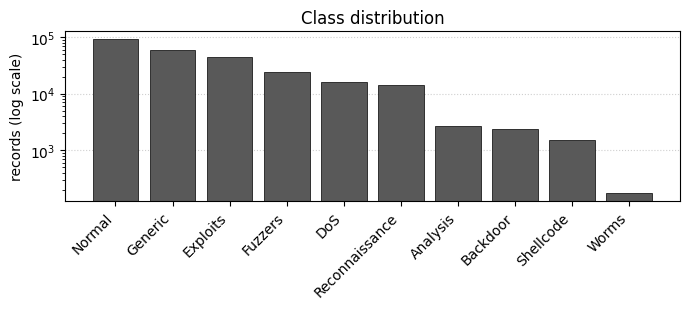

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(range(len(counts)), counts.values, color="0.35", edgecolor="black", linewidth=0.5)
ax.set_yscale("log")
ax.set_xticks(range(len(counts)))
ax.set_xticklabels([CLASS_NAMES[c] for c in counts.index], rotation=45, ha="right")
ax.set_ylabel("records (log scale)")
ax.set_title("Class distribution")
ax.grid(axis="y", linestyle=":", alpha=0.6); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 3. What is wrong with the data

Before choosing any preprocessing, measure the actual problems.

In [5]:
num = X[numeric_columns(X)]

facts = {
    "records": len(X),
    "features with missing values": int((X == "unknown").any().sum()),
    "missing in 'service' (%)": round(100 * (X["service"] == "unknown").mean(), 2),
    "largest skew": round(num.skew().max(), 1),
    "most skewed feature": num.skew().idxmax(),
    "widest numeric range": f"{(num.max() - num.min()).max():,.0f}",
    "protocol categories": int(X["proto"].nunique()),
}
for k, v in facts.items():
    print(f"{k:32s}: {v}")

records                         : 257673
features with missing values    : 1
missing in 'service' (%)        : 54.85
largest skew                    : 173.2
most skewed feature             : trans_depth
widest numeric range            : 5,988,000,256
protocol categories             : 133


Four problems matter.

**Lopsided classes.** 534 to 1 between biggest and smallest.

**Missing values.** Over half the records have no value for `service`. Too many
to delete, and filling them in would be inventing data for most of the dataset.
So "missing" was made its own category.

**Skew.** Some features have a few enormous values and a huge pile of tiny ones.
This breaks the obvious way of rescaling numbers, as section 5 shows.

**Wildly different ranges.** One feature spans about 6 billion, another spans 1.
k-NN adds up differences across features, so without rescaling the big feature
drowns out everything else.

In [6]:
rng = (num.max() - num.min()).sort_values(ascending=False)
print("widest and narrowest numeric ranges\n")
print(pd.concat([rng.head(4), rng.tail(4)]).apply(lambda v: f"{v:,.2f}").to_string())

widest and narrowest numeric ranges

sload              5,988,000,256.00
stcpb              4,294,958,913.00
dtcpb              4,294,881,924.00
dload                 22,422,730.00
tcprtt                         3.82
synack                         3.23
ackdat                         2.93
is_sm_ips_ports                1.00


## 4. Two different preprocessing recipes

This is the core idea of the assignment. The two models are broken by different
things, so they get different preparation.

**k-NN** measures distance across all features at once, so it cares a lot about
scale, and about how categories are encoded.

**The tree** only ever asks "is this feature above or below some cut-off?".
Stretching a feature does not change the answer, so rescaling it is pointless
work.

In [7]:
from a2_common import build_knn_preprocessor, build_ct_preprocessor

numcols = numeric_columns(X)
knn_prep = build_knn_preprocessor(numcols)
ct_prep  = build_ct_preprocessor(numcols)

print("k-NN recipe:")
for name, trans, cols in knn_prep.transformers:
    print(f"   {name:6s} -> {trans if isinstance(trans, str) else [s[0] for s in trans.steps]}")
print("\ntree recipe:")
for name, trans, cols in ct_prep.transformers:
    print(f"   {name:6s} -> {trans if isinstance(trans, str) else [s[0] for s in trans.steps]}")

k-NN recipe:
   num    -> ['constant', 'scale']
   nom    -> ['rare', 'onehot']

tree recipe:
   num    -> passthrough
   nom    -> ['ordinal']


In words:

| Step | k-NN | Tree |
|---|---|---|
| Drop the `id` column | yes | yes |
| Missing `service` becomes its own category | yes | yes |
| Rare `proto` categories grouped together | yes | no |
| Category encoding | one-hot | ordinal |
| Rescale numbers | yes, rank based | **no** |
| Drop constant columns | yes | no |

The `id` column is dropped for both. Records were saved in time order, so `id`
leaks which attack burst a record came from. Section 6 shows how much that
inflates the score.

In [8]:
Z = knn_prep.fit_transform(X.head(5000), y.head(5000))
print(f"k-NN turns {X.shape[1]} columns into {Z.shape[1]} numbers, all between 0 and 1")
print(f"min={Z.min():.3f}  max={Z.max():.3f}")
Zt = ct_prep.fit_transform(X.head(5000), y.head(5000))
print(f"\ntree keeps {Zt.shape[1]} columns and leaves the numbers alone")
print(f"min={Zt.min():,.1f}  max={Zt.max():,.1f}")

k-NN turns 42 columns into 184 numbers, all between 0 and 1
min=0.000  max=1.000

tree keeps 42 columns and leaves the numbers alone
min=0.0  max=4,294,718,197.0


## 5. Why the rank transform, and not min-max

Min-max rescaling maps the smallest value to 0 and the largest to 1. That sounds
fine until the largest value is an extreme outlier. Then almost every ordinary
record gets squashed into a tiny sliver near zero and stops mattering.

The rank transform instead replaces each value by its **position** in the sorted
order. Smallest becomes 0, middle becomes 0.5, largest becomes 1. The gaps
between outliers disappear, but the ordering is kept.

Five options were compared on the tuning data.

In [9]:
sc = pd.read_csv(f"{RESULTS}/scaling_study.csv")
print(sc[["transformation", "bal_mean", "bal_std", "f1_mean"]].round(4).to_string(index=False))
best, worst = sc.iloc[0], sc[sc.transformation == "min-max"].iloc[0]
print(f"\nrank beats min-max by {best.bal_mean - worst.bal_mean:.4f}"
      f"  ({100*(best.bal_mean-worst.bal_mean)/worst.bal_mean:.1f}% better)")

           transformation  bal_mean  bal_std  f1_mean
               rank based    0.4762   0.0119   0.4851
logarithmic, then min-max    0.4740   0.0106   0.4883
       robust to outliers    0.4614   0.0222   0.4716
                  z-score    0.4190   0.0075   0.4244
                  min-max    0.4133   0.0079   0.4171



rank beats min-max by 0.0629  (15.2% better)


One honest caveat, which is stated in the report too. This study was scored on
balanced accuracy. Under macro F1, which became the main metric later, rank and
"log then min-max" are too close to separate (0.485 versus 0.488, well inside
the fold-to-fold wobble). Rank was kept for the reason above, not because the
numbers separate them.

## 6. Does every preprocessing step earn its place?

Each step was switched off one at a time, and the drop in score measured. A step
that changes nothing is not worth doing.

In [10]:
ak = pd.read_csv(f"{RESULTS}/ablation_knn.csv")
ac = pd.read_csv(f"{RESULTS}/ablation_ct.csv")
print("k-NN\n" + ak[["variant", "bal_mean", "f1_mean"]].round(4).to_string(index=False))
print("\ntree\n" + ac[["variant", "bal_mean", "f1_mean"]].round(4).to_string(index=False))

k-NN
                 variant  bal_mean  f1_mean
       selected pipeline    0.4744   0.4853
              no scaling    0.3192   0.3231
 min-max instead of rank    0.4160   0.4190
correlation filter added    0.4597   0.4702
  no rare-level grouping    0.4738   0.4850
     identifier retained    0.4794   0.4913

tree
                   variant  bal_mean  f1_mean
         selected pipeline    0.6084   0.5218
     min-max scaling added    0.6065   0.5212
  correlation filter added    0.5910   0.4966
one-hot instead of ordinal    0.6062   0.5224
       identifier retained    0.6424   0.5619


Three things to notice.

**Scaling is everything for k-NN.** Removing it drops the score from 0.474 to
0.319. That is the biggest single effect in the whole study.

**Scaling does nothing for the tree.** 0.6084 versus 0.6065. Noise. Exactly as
predicted, because a tree only cares about ordering.

**Keeping `id` makes both look better than they are.** The tree jumps from 0.608
to 0.642. That is not skill, it is the model reading the capture order. This is
why `id` is dropped.

There was also a surprise. Dropping strongly correlated features **hurt**, even
though the theory says duplicated information should be removed.

In [11]:
rd = pd.read_csv(f"{RESULTS}/redundancy_study.csv")
print(rd[["setting", "threshold", "bal_mean", "f1_mean"]].round(4).to_string(index=False))

                   setting  threshold  bal_mean  f1_mean
    every feature retained        NaN    0.4762   0.4851
correlation filter at 0.99       0.99    0.4752   0.4840
correlation filter at 0.95       0.95    0.4593   0.4711
correlation filter at 0.90       0.90    0.4603   0.4725


The strongest pair correlates at 0.9989, not 1.0. The leftover 0.11 percent is
the handful of records where the two features disagree, and those records turn
out to be informative. So the filter was not used. The measurement was reported
instead of the expectation.

## 7. Choosing the settings

Every combination on a grid was tried, using 5-fold cross-validation on the
tuning quarter of the data. The other three quarters were never touched during
this, so the final scores are not flattered by the search.

In [12]:
kg = pd.read_csv(f"{RESULTS}/tune_knn_final.csv")
top = kg.sort_values("f1_mean", ascending=False).head(6)
print("best k-NN settings\n")
print(top[["k", "weights", "metric", "bal_mean", "f1_mean"]].round(4).to_string(index=False))

best k-NN settings

 k  weights    metric  bal_mean  f1_mean
 5 distance manhattan    0.4886   0.5028
 7 distance manhattan    0.4876   0.5021
 9 distance manhattan    0.4834   0.4952
 3 distance manhattan    0.4846   0.4926
 5  uniform manhattan    0.4751   0.4914
 1 distance manhattan    0.4882   0.4904


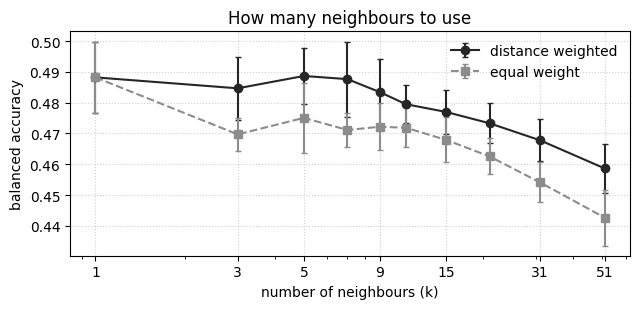

In [13]:
sub = kg[(kg.weights == "distance") & (kg.metric == "manhattan")].sort_values("k")
sub2 = kg[(kg.weights == "uniform") & (kg.metric == "manhattan")].sort_values("k")
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.errorbar(sub.k, sub.bal_mean, yerr=sub.bal_std, fmt="o-", color="0.15",
            capsize=2, label="distance weighted")
ax.errorbar(sub2.k, sub2.bal_mean, yerr=sub2.bal_std, fmt="s--", color="0.55",
            capsize=2, label="equal weight")
ax.set_xscale("log"); ax.set_xticks([1,3,5,9,15,31,51])
ax.get_xaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
ax.set_xlabel("number of neighbours (k)"); ax.set_ylabel("balanced accuracy")
ax.set_title("How many neighbours to use")
ax.legend(frameon=False); ax.grid(linestyle=":", alpha=0.6); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

Small `k` is jumpy because a single odd neighbour can decide the answer. Large
`k` smooths too much and the rare classes get outvoted. Distance weighting, where
closer neighbours count more, beats treating all neighbours equally.

## 8. How hard to push the rare classes

A tree normally ignores rare classes, because a leaf holding 20 records barely
affects overall purity. The usual fix is "class weighting": pretend one rare
record is worth many common ones.

The standard setting weights each class by 1 divided by how common it is. That
turned out to push **too hard**. So the weight was given a dial:

$$w_c = \left(\frac{N}{K \cdot n_c}\right)^{\alpha}$$

$\alpha = 0$ means no weighting at all. $\alpha = 1$ is the standard setting.
Anything in between is a partial push.

In [14]:
sw = pd.read_csv(f"{RESULTS}/rev_alpha_sweep.csv")
sw["meaning"] = ["no weighting", "", "", "", "standard setting"]
print(sw.round(4).to_string(index=False))

 alpha  f1_mean  bal_mean          meaning
  0.00   0.5392    0.5253     no weighting
  0.25   0.5461    0.5593                 
  0.50   0.5519    0.6056                 
  0.75   0.5585    0.6434                 
  1.00   0.5450    0.6456 standard setting


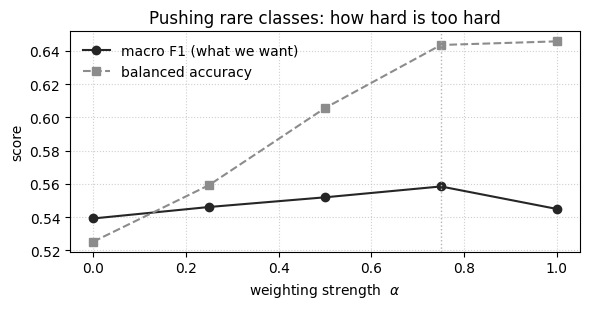

In [15]:
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(sw.alpha, sw.f1_mean, "o-", color="0.15", label="macro F1 (what we want)")
ax.plot(sw.alpha, sw.bal_mean, "s--", color="0.55", label="balanced accuracy")
ax.axvline(0.75, color="0.7", linestyle=":", linewidth=1)
ax.set_xlabel(r"weighting strength  $\alpha$"); ax.set_ylabel("score")
ax.set_title("Pushing rare classes: how hard is too hard")
ax.legend(frameon=False); ax.grid(linestyle=":", alpha=0.6); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

The two curves peak in different places. Balanced accuracy keeps rising to
$\alpha = 1$, because it only counts how many rare records you catch and never
punishes false alarms. Macro F1 peaks at $\alpha = 0.75$ and then falls, because
it also counts the false alarms.

This is why the metric you choose changes the model you end up with.

## 9. Changing how the final answer is picked

Both models really output a **probability for each class**, then pick the
biggest. The multiplier trick says: do not just pick the biggest, pick the
biggest after scaling each class by a number tuned for the job.

$$\hat{y} = \arg\max_c \; c_m \cdot P(\text{class } m \mid x)$$

Setting every multiplier to 1 gives back the ordinary rule, so the search can
never make things worse. The multipliers were fitted on the tuning data only,
then applied unchanged to the evaluation data.

In [16]:
mp = pd.read_csv(f"{RESULTS}/rev_multipliers.csv", index_col=0)
print(mp.T.round(2).to_string())

                k-NN  k-NN + SMOTE  tree  tree + SMOTE
Normal          0.40          0.55  1.50          1.50
Reconnaissance  0.20          0.50  0.50          0.50
Backdoor        1.90          0.35  0.20          0.85
DoS             2.30          2.00  1.60          1.80
Exploits        1.00          1.00  1.60          1.70
Analysis        2.00          0.45  0.75          0.95
Fuzzers         0.75          1.00  1.00          0.95
Worms           5.70          0.30  1.00          0.20
Shellcode       1.40          0.20  0.20          0.20
Generic         2.00          2.00  0.65          1.10


Read the `tree` column. Shellcode gets 0.20, which tells the model to stop
over-predicting it. Normal gets 1.50 and Exploits 1.60, which recovers the
records that the over-prediction had stolen from them.

There was a nice surprise for k-NN. The best number of neighbours **changes**
once you use this rule.

In [17]:
kk = pd.read_csv(f"{RESULTS}/rev_knn_k.csv")
kk["gain"] = (kk.tuned - kk.plain).round(4)
kk.columns = ["k", "ordinary rule", "with multipliers", "gain"]
print(kk.round(4).to_string(index=False))

 k  ordinary rule  with multipliers   gain
 5         0.5034            0.5252 0.0218
15         0.4878            0.5270 0.0392
31         0.4796            0.5283 0.0487


`k = 31` is the **worst** setting under the ordinary rule and the **best** one
with multipliers. The reason: with only 5 neighbours the vote share can only
take a few values, so there is almost nothing for a multiplier to flip. More
neighbours give a finer-grained probability, which gives the multipliers
something to work with.

## 10. Final results

Four setups, scored with stratified 10-fold cross-validation on the evaluation
data, which nothing in the tuning ever saw.

In [18]:
s = pd.read_csv(f"{RESULTS}/final_summary.csv", index_col=0)
show = s[["f1_macro_mean", "balanced_accuracy_mean", "f1_weighted_mean",
          "mcc_mean", "accuracy_mean"]].round(4)
show.columns = ["macro F1", "balanced acc", "weighted F1", "correlation", "accuracy"]
print(show.to_string())

               macro F1  balanced acc  weighted F1  correlation  accuracy
configuration                                                            
k-NN             0.5436        0.5480       0.8046       0.7411    0.7949
k-NN + SMOTE     0.5339        0.5813       0.8002       0.7361    0.7894
tree             0.5893        0.6516       0.7981       0.7328    0.7830
tree + SMOTE     0.5646        0.6209       0.7974       0.7314    0.7835


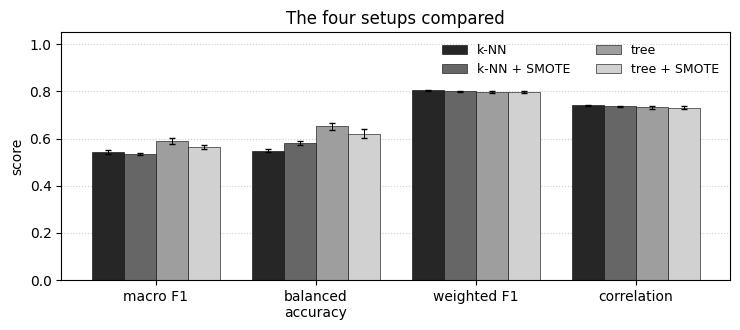

In [19]:
folds = pd.read_csv(f"{RESULTS}/v2_folds.csv")
order = ["k-NN", "k-NN + SMOTE", "tree", "tree + SMOTE"]
mets = ["f1_macro", "balanced_accuracy", "f1_weighted", "mcc"]
labs = ["macro F1", "balanced\naccuracy", "weighted F1", "correlation"]
fig, ax = plt.subplots(figsize=(7.5, 3.4))
xs = np.arange(len(mets)); w = 0.2
for i, n in enumerate(order):
    d = folds[folds.configuration == n]
    ax.bar(xs + (i - 1.5) * w, [d[m].mean() for m in mets], w,
           yerr=[d[m].std(ddof=1) for m in mets], label=n,
           color=["0.15", "0.40", "0.62", "0.82"][i],
           edgecolor="black", linewidth=0.4, error_kw=dict(lw=0.7, capsize=2))
ax.set_xticks(xs); ax.set_xticklabels(labs); ax.set_ylim(0, 1.05)
ax.set_ylabel("score"); ax.set_title("The four setups compared")
ax.legend(frameon=False, ncol=2, fontsize=9)
ax.grid(axis="y", linestyle=":", alpha=0.6); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

**Neither model wins outright, and that is the interesting part.**

The tree wins on macro F1 and balanced accuracy. Those treat every class as
equally important. k-NN wins on accuracy, weighted F1 and the correlation
coefficient. Those weight by how many records a class has.

Both are correct. They are measuring different things. Section 11 shows exactly
why.

Also notice SMOTE, which invents extra rare-class records, made **both** models
worse here. Once the decision rule is already cost sensitive, adding SMOTE on
top over-corrects. Fix imbalance once, not twice.

## 11. Where the difference actually comes from

In [20]:
p = pd.read_csv(f"{RESULTS}/final_perclass.csv", index_col=0)
cls = pd.read_csv(f"{RESULTS}/audit_classes.csv").set_index("class")
rows = []
for n in cls.sort_values("count", ascending=False).index:
    k, t = p.loc["k-NN", f"recall_{n}_mean"], p.loc["tree", f"recall_{n}_mean"]
    rows.append([n, int(cls.loc[n, "count"]), round(k, 3), round(t, 3),
                 "k-NN" if k - t > 0.005 else ("tree" if t - k > 0.005 else "tie")])
pc = pd.DataFrame(rows, columns=["class", "records", "k-NN recall", "tree recall", "better"])
print(pc.to_string(index=False))

         class  records  k-NN recall  tree recall better
        Normal    93000        0.879        0.814   k-NN
       Generic    58871        0.977        0.977    tie
      Exploits    44525        0.605        0.566   k-NN
       Fuzzers    24246        0.680        0.723   tree
           DoS    16353        0.703        0.805   tree
Reconnaissance    13987        0.655        0.748   tree
      Analysis     2677        0.131        0.271   tree
      Backdoor     2329        0.075        0.100   tree
     Shellcode     1511        0.566        0.735   tree
         Worms      174        0.208        0.777   tree


There it is. k-NN is better on Normal and Exploits, which between them are
53 percent of all records. The tree is better on seven classes that together are
only 24 percent of records. Generic is a tie.

So a metric that counts records favours k-NN, and a metric that counts classes
favours the tree. Same models, same predictions, different question.

Look at Worms: k-NN catches 21 percent, the tree catches 78 percent. For
intrusion detection, missing four out of five instances of an attack type is a
real failure, even if the overall accuracy looks fine.

## 12. Are the differences real?

A single number could be luck. Two tests were used. First a Friedman test asks
"are these four setups the same or not?". If that says no, Wilcoxon tests compare
each pair, with a Holm correction because running six tests at once makes a lucky
result more likely.

In [21]:
fr = pd.read_csv(f"{RESULTS}/stats_friedman.csv").iloc[0]
print(f"Friedman: chi-squared = {fr.statistic:.1f},  p = {fr.p_value:.2e}")
print(f"  -> the four setups are NOT the same\n")
pw = pd.read_csv(f"{RESULTS}/stats_pairwise.csv")
print(pw[["comparison", "mean_difference", "wilcoxon_p", "holm_p", "significant"]]
      .round(5).to_string(index=False))

Friedman: chi-squared = 30.0,  p = 1.38e-06
  -> the four setups are NOT the same

                  comparison  mean_difference  wilcoxon_p  holm_p  significant
        k-NN vs k-NN + SMOTE          0.00972     0.00195 0.01172         True
                k-NN vs tree         -0.04564     0.00195 0.01172         True
        k-NN vs tree + SMOTE         -0.02098     0.00195 0.01172         True
        k-NN + SMOTE vs tree         -0.05536     0.00195 0.01172         True
k-NN + SMOTE vs tree + SMOTE         -0.03070     0.00195 0.01172         True
        tree vs tree + SMOTE          0.02466     0.00195 0.01172         True


A chi-squared of 30.0 is the **highest value possible** for four setups over ten
folds. That means the ranking was identical in every single fold, not just on
average. All six pairs stay significant after correction.

## 13. How good could anyone possibly get?

Macro F1 of 0.59 sounds low. The fair question is whether that is the models
failing or the data being hard. This can be answered exactly.

Imagine a cheating model that memorises the entire dataset, and for every
distinct combination of feature values predicts whichever class is most common
among the records that share it. No honest model can beat it.

In [22]:
cs = pd.read_csv(f"{RESULTS}/ceiling_summary.csv").iloc[0]
tree_f1 = float(pd.read_csv(f"{RESULTS}/final_summary.csv", index_col=0)
                .loc["tree", "f1_macro_mean"])
print(f"pure memorisation, tested honestly     : {cs.macro_f1_memorisation_cv:.4f}")
print(f"OUR TREE                               : {tree_f1:.4f}")
print(f"upper bound, {100*(1-cs.matched_fraction):.0f}% of answers given free : "
      f"{cs.macro_f1_gifted_cv:.4f}")
print(f"cheating model that saw every record   : {cs.macro_f1_resubstitution:.4f}")

pure memorisation, tested honestly     : 0.3181
OUR TREE                               : 0.5893
upper bound, 56% of answers given free : 0.7576
cheating model that saw every record   : 0.7774


In [23]:
cp = pd.read_csv(f"{RESULTS}/ceiling_perclass.csv").set_index("class")
comp = pd.DataFrame({
    "memorised per record": cp["ceiling_resubstitution"].round(3),
    "our tree": [round(p.loc["tree", f"recall_{n}_mean"], 3) for n in cp.index],
})
print(comp.to_string())

                best possible  our tree
class                                  
Normal                  0.996     0.814
Reconnaissance          0.914     0.748
Backdoor                0.265     0.100
DoS                     0.539     0.805
Exploits                0.812     0.566
Analysis                0.375     0.271
Fuzzers                 0.924     0.723
Worms                   0.957     0.777
Shellcode               0.996     0.735
Generic                 0.997     0.977


One caution on the last line above. Predicting the most common class of
each repeated feature vector is the best possible for *accuracy*, not for
macro F1, which is an average over classes rather than a sum over records.
Reweighting the same counts per class reaches 0.7833. So treat 0.7774 as a
reference point, not a hard ceiling.

Three classes cap everything: Backdoor at 0.265, Analysis at 0.375, DoS at 0.539.
Their records are near-copies of Exploits, and 22 191 records carry a label other than the most
frequent label of their own feature vector. Nothing can separate those.

Because of those three, reaching a macro F1 of 0.70 would need every other class
to score above 0.83. So scores near 0.70 on this dataset are a sign of a leak,
not a better model. Keeping the `id` column, for instance, makes every record
unique and pushes the cheating ceiling to a perfect 1.0.

Our tree sits 85 percent above what memorising achieves. The models are doing
their job; the data has a hard limit.

## 14. Running a model yourself

Everything above used saved results. This section actually fits both models so
you can see the code work end to end. With `QUICK = True` it uses a sample and
three folds.

In [24]:
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, balanced_accuracy_score, accuracy_score
from a2_step6_retune_f1 import PowerWeightedTree

if QUICK:
    Xs, _, ys, _ = train_test_split(X, y, train_size=40_000, stratify=y, random_state=42)
    Xs, ys, folds_n = Xs.reset_index(drop=True), ys.reset_index(drop=True), 3
else:
    _, Xs, _, ys = train_test_split(X, y, train_size=0.25, stratify=y, random_state=42)
    Xs, ys, folds_n = Xs.reset_index(drop=True), ys.reset_index(drop=True), 10

nc = numeric_columns(Xs)
models = {
    "k-NN":  Pipeline([("prep", build_knn_preprocessor(nc)),
                       ("clf", KNeighborsClassifier(n_neighbors=5, weights="distance",
                                                    metric="manhattan", n_jobs=-1))]),
    "tree":  Pipeline([("prep", build_ct_preprocessor(nc)),
                       ("clf", PowerWeightedTree(alpha=0.75, criterion="entropy",
                                                 max_depth=13, min_samples_leaf=2,
                                                 ccp_alpha=1e-5, random_state=42))]),
}

skf = StratifiedKFold(n_splits=folds_n, shuffle=True, random_state=42)
out = []
for name, pipe in models.items():
    for f, (tr, te) in enumerate(skf.split(Xs, ys), 1):
        pipe.fit(Xs.iloc[tr], ys.iloc[tr])
        pred = pipe.predict(Xs.iloc[te])
        out.append(dict(model=name, fold=f,
                        macro_f1=f1_score(ys.iloc[te], pred, average="macro", zero_division=0),
                        balanced_acc=balanced_accuracy_score(ys.iloc[te], pred),
                        accuracy=accuracy_score(ys.iloc[te], pred)))
    print(f"{name} done")

res = pd.DataFrame(out)
print("\naverages over folds:")
print(res.groupby("model")[["macro_f1", "balanced_acc", "accuracy"]].mean().round(4).to_string())

k-NN done


tree done

averages over folds:
       macro_f1  balanced_acc  accuracy
model                                  
k-NN     0.4818        0.4715    0.7881
tree     0.5453        0.6181    0.7614


These will not match the report exactly in quick mode, because they use a
fraction of the data and three folds instead of ten. The reported numbers are the
ones in section 10. Set `QUICK = False` to reproduce them properly.

## 15. Summary

**The tree is the better model for this problem.** Macro F1 0.589 against 0.544,
balanced accuracy 0.652 against 0.548. Every difference is statistically
significant and the ranking held in all ten folds.

**k-NN is better if you only care about volume.** Accuracy 0.795 against 0.783.
For intrusion detection that is the wrong thing to care about, because it means
missing rare attacks.

**Five things worth remembering:**

1. Preprocessing belongs to the algorithm, not the dataset. The two recipes here
   share only one step.
2. The rank transform beats min-max by 15 percent on this data, purely because of
   skew.
3. Theory can be wrong. Dropping correlated features looked obviously right and
   made things worse.
4. The metric you pick decides the model you get. Balanced accuracy and macro F1
   chose different settings.
5. Fix class imbalance once. Weighting plus SMOTE was worse than weighting alone.